<a href="https://colab.research.google.com/github/Pranayshukla0610/Data-Science-Projects/blob/main/AI_Generated_Face_Image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install diffusers transformers accelerate safetensors torch torchvision opencv-python pillow matplotlib -q

In [ ]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
print("CUDA Available:",torch.cuda.is_available())

CUDA Available: True


In [ ]:
model_id = 'runwayml/stable-diffusion-v1-5'

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype = torch.float16
)

pipe = pipe.to('cuda')

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
prompt = """
ultra realistic human face,
young businessman,
cinematic portrait,
sharp jawline,
studio lighting,
highly detailed skin,
8k,
professional photography
"""

In [ ]:
negative_prompt = """
blurry,
low quality,
extra eyes,
deformed face,
bad anatomy,
cropped image,
distorted skin
"""

In [ ]:
image = pipe(
    prompt=prompt,
    negative_prompt = negative_prompt,
    guidance_scale=8.5,
    num_inference_steps=40,
    height=512,
    width=512
).images[0]

  0%|          | 0/40 [00:00<?, ?it/s]

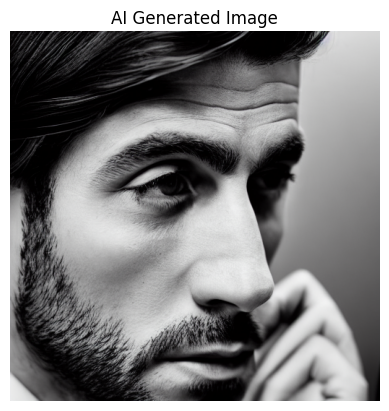

In [ ]:
plt.imshow(image)
plt.axis('off')
plt.title('AI Generated Image')
plt.show()

In [ ]:
image.save("ai_face.png")

print("AI face generated successfully!")

AI face generated successfully!
